# Proyecto de Análisis de Churn - Model Fitness

## Introducción

En este proyecto se aborda un problema clave en la industria del fitness: la **pérdida de clientes (churn)**. La cadena de gimnasios *Model Fitness* busca desarrollar una estrategia basada en datos para mejorar la retención de usuarios y anticiparse a posibles cancelaciones.

El churn representa uno de los principales desafíos para cualquier negocio basado en suscripciones, ya que impacta directamente en los ingresos y el crecimiento sostenible. Identificar patrones de comportamiento que indiquen abandono permite a las empresas tomar decisiones estratégicas más informadas.

## Objetivos del Proyecto

Los objetivos principales de este análisis son:

- Predecir la probabilidad de cancelación de clientes en el próximo mes.
- Identificar perfiles típicos de usuarios mediante técnicas de segmentación.
- Analizar los factores que influyen en la pérdida de clientes.
- Proponer recomendaciones basadas en datos para mejorar la retención.

## Descripción de los Datos

El conjunto de datos incluye información demográfica, comportamiento de uso y detalles de la membresía de los clientes. Entre las variables más relevantes se encuentran:

- Información del usuario: género, edad, tiempo como cliente.
- Actividad: frecuencia de visitas, participación en clases grupales.
- Contrato: duración, tiempo restante.
- Consumo adicional: gastos en servicios complementarios.
- Variable objetivo: **Churn** (cancelación del cliente).

## Metodología

El análisis se desarrollará en varias etapas:

1. **Análisis Exploratorio de Datos (EDA)** para comprender la distribución y relaciones entre variables.
2. **Modelado predictivo** utilizando algoritmos como regresión logística y bosque aleatorio.
3. **Clustering** para segmentar a los clientes en grupos con características similares.
4. **Conclusiones y recomendaciones** orientadas a la toma de decisiones estratégicas.

## Resultado Esperado

Se espera obtener insights accionables que permitan:

- Detectar clientes en riesgo de abandono.
- Diseñar estrategias de fidelización más efectivas.
- Optimizar la experiencia del cliente dentro del gimnasio.

---

> Este proyecto simula un caso real de análisis de datos en el ámbito empresarial, integrando técnicas de machine learning y análisis exploratorio para la toma de decisiones basada en datos.

## Importamos las librerías de python y el conjunto de datos

In [1]:
# Librerías para análisis de datos y operaciones numéricas
import pandas as pd
import numpy as np

# Librerías para visualización de datos
import matplotlib.pyplot as plt
import seaborn as sns

# Herramientas de machine learning (modelos, métricas y preprocesamiento)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.preprocessing import StandardScaler

# Algoritmos de clustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import KMeans

In [3]:
# Cargar el dataset desde un archivo CSV en un DataFrame
df = pd.read_csv('gym_churn_us.csv')

## Exploración inicial de datos

In [ ]:
# Visualizar las primeras filas y obtener información general del dataset
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64  
 3   Promo_friends                      4000 non-null   int64  
 4   Phone                              4000 non-null   int64  
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits                       4000 non-null   int64  
 7   Age                                4000 non-null   int64  
 8   Avg_additional_charges_total       4000 non-null   float64
 9   Month_to_end_contract              4000 non-null   float64
 10  Lifetime                           4000 non-null   int64  
 11  Avg_class_frequency_total          4000 non-null   float

Nos damos cuenta de que los nombres de las columnas no cumplen con la estandarización de snake_case, así que estos serán cambiados.

In [ ]:
# Renombrar las columnas para estandarizar los nombres en minúsculas
df = df.rename(columns={
    'Near_Location': 'near_location',
    'Partner': 'partner',
    'Promo_friends': 'promo_friends',
    'Phone': 'phone',
    'Contract_period': 'contract_period',
    'Group_visits': 'group_visits',
    'Age': 'age',
    'Avg_additional_charges_total': 'avg_additional_charges_total',
    'Month_to_end_contract': 'month_to_end_contract',
    'Lifetime': 'lifetime',
    'Avg_class_frequency_total': 'avg_class_frequency_total',
    'Avg_class_frequency_current_month': 'avg_class_frequency_current_month',
    'Churn': 'churn'
})

In [ ]:
# Mostrar información general del DataFrame (tipos de datos, valores no nulos, etc.)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   near_location                      4000 non-null   int64  
 2   partner                            4000 non-null   int64  
 3   promo_friends                      4000 non-null   int64  
 4   phone                              4000 non-null   int64  
 5   contract_period                    4000 non-null   int64  
 6   group_visits                       4000 non-null   int64  
 7   age                                4000 non-null   int64  
 8   avg_additional_charges_total       4000 non-null   float64
 9   month_to_end_contract              4000 non-null   float64
 10  lifetime                           4000 non-null   int64  
 11  avg_class_frequency_total          4000 non-null   float

Los nombres de las columnas ya fueron cambiados, no hay mayúsculas, ni espacios.

## Revisión de valores nulos

In [ ]:
# Verificar la cantidad de valores faltantes por cada columna
df.isna().sum()

gender                               0
near_location                        0
partner                              0
promo_friends                        0
phone                                0
contract_period                      0
group_visits                         0
age                                  0
avg_additional_charges_total         0
month_to_end_contract                0
lifetime                             0
avg_class_frequency_total            0
avg_class_frequency_current_month    0
churn                                0
dtype: int64

No se encuentraron valores nulos en este conjunto de datos.

### Estadística descriptiva 

In [ ]:
# Obtener estadísticas descriptivas de las variables numéricas
df.describe()

,gender,near_location,partner,promo_friends,phone,contract_period,group_visits,age,avg_additional_charges_total,month_to_end_contract,lifetime,avg_class_frequency_total,avg_class_frequency_current_month,churn
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,0.510250,0.845250,0.486750,0.308500,0.903500,4.681250,0.412250,29.184250,146.943728,4.322750,3.724750,1.879020,1.767052,0.265250
std,0.499957,0.361711,0.499887,0.461932,0.295313,4.549706,0.492301,3.258367,96.355602,4.191297,3.749267,0.972245,1.052906,0.441521
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,18.000000,0.148205,1.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,27.000000,68.868830,1.000000,1.000000,1.180875,0.963003,0.000000
50%,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,29.000000,136.220159,1.000000,3.000000,1.832768,1.719574,0.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,6.000000,1.000000,31.000000,210.949625,6.000000,5.000000,2.536078,2.510336,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,12.000000,1.000000,41.000000,552.590740,12.000000,31.000000,6.023668,6.146783,1.000000


### Análisis de estadísticas descriptivas

**Valores faltantes:**
- No se observan valores ausentes en el dataset. Todas las variables tienen un conteo de 4000 registros, lo que indica que los datos están completos.

**Promedios (mean):**
- Edad promedio: ~29.18 años.
- Frecuencia promedio de visitas (total): ~1.88 veces por semana.
- Frecuencia promedio en el mes actual: ~1.77 veces por semana.
- Gasto adicional promedio: ~146.94.
- Duración promedio del contrato: ~4.68 meses.

**Desviación estándar (std):**
- La edad presenta baja variabilidad (~3.26), lo que indica que la mayoría de los clientes están en un rango similar.
- El gasto adicional muestra alta variabilidad (~96.36), lo que sugiere diferentes niveles de consumo entre clientes.
- La frecuencia de visitas tiene una variación moderada (~0.97 total, ~1.05 actual).

**Conclusiones:**
- Los clientes tienen un comportamiento relativamente homogéneo en edad.
- Existe una diferencia considerable en el gasto adicional, lo que puede ser un factor importante para segmentación.
- La frecuencia de visitas es relativamente baja (menos de 2 veces por semana en promedio), lo que podría ser un indicador clave para analizar la retención.

**Insight:**
Los clientes con mayor frecuencia de visitas y mayor gasto adicional probablemente presentan un mayor nivel de compromiso con el gimnasio, lo que podría reducir la probabilidad de cancelación.

## Clientes que se quedaron en el gym vs clientes que se fueron

In [ ]:
# Agrupar los datos por la variable churn y calcular el promedio de cada columna
df.groupby('churn').mean()

,gender,near_location,partner,promo_friends,phone,contract_period,group_visits,age,avg_additional_charges_total,month_to_end_contract,lifetime,avg_class_frequency_total,avg_class_frequency_current_month
churn,,,,,,,,,,,,,
0,0.510037,0.873086,0.534195,0.353522,0.903709,5.747193,0.464103,29.976523,158.445715,5.283089,4.711807,2.024876,2.027882
1,0.510839,0.768143,0.355325,0.183789,0.902922,1.728558,0.268615,26.989632,115.082899,1.662582,0.990575,1.474995,1.044546


Los clientes que cancelan tienen menor frecuencia de visitas y contratos más cortos.

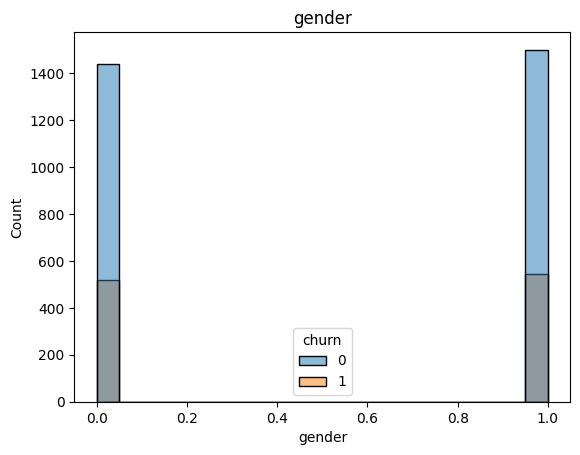

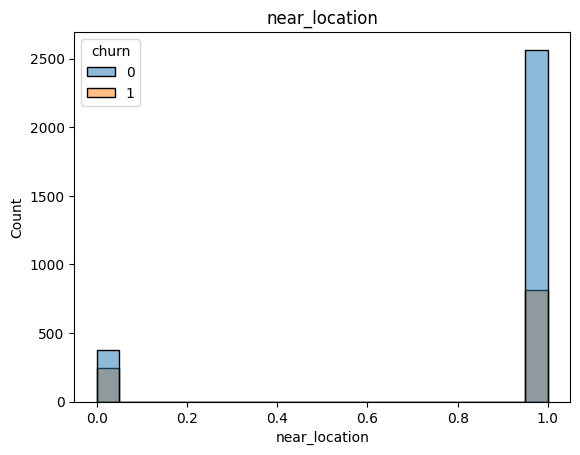

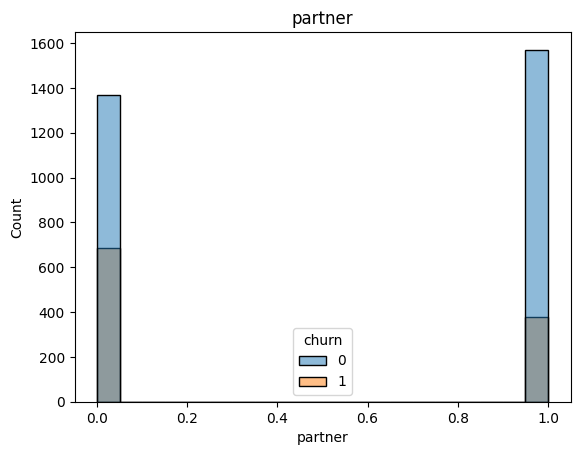

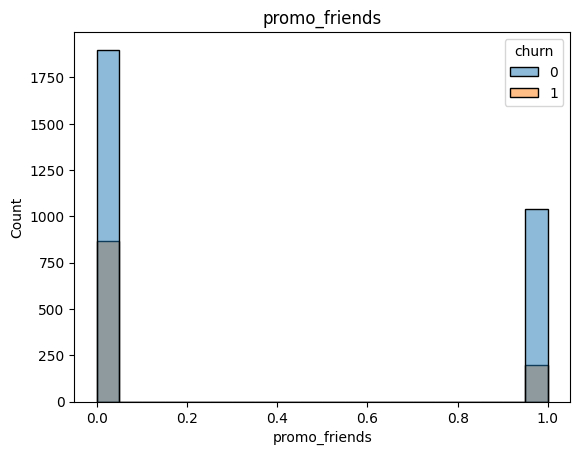

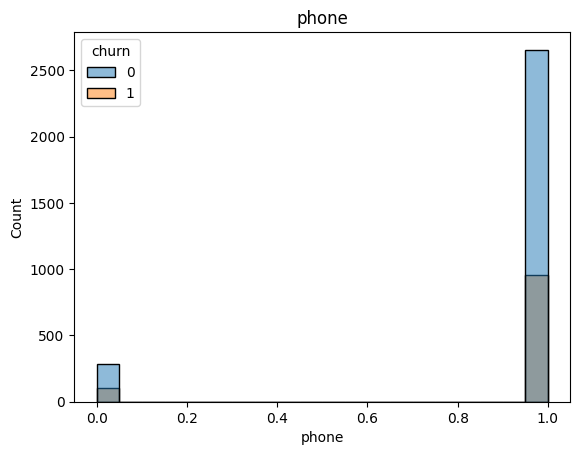

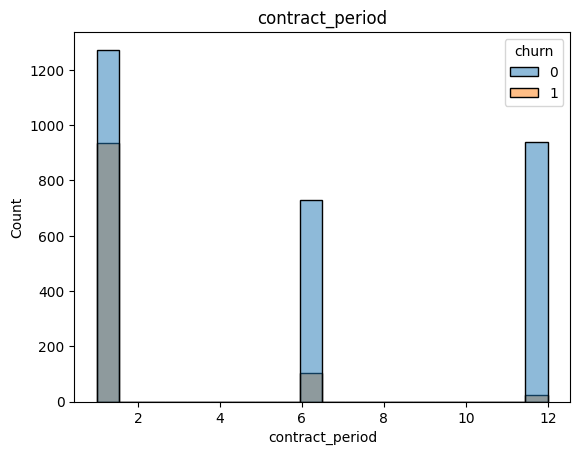

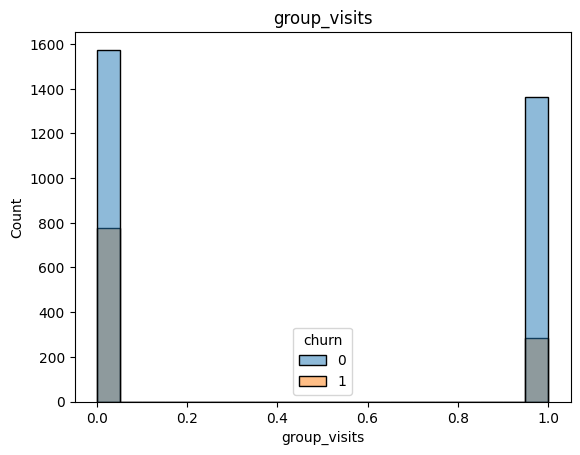

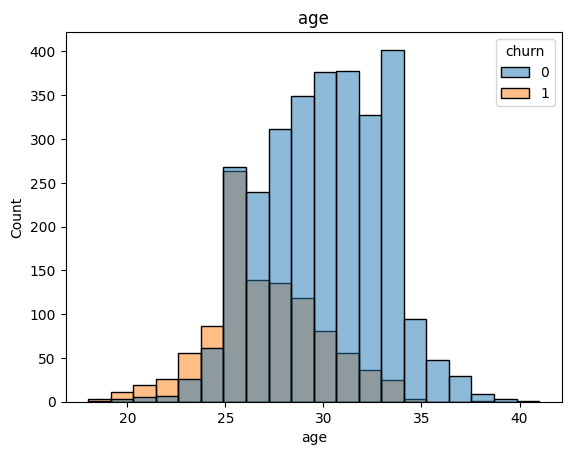

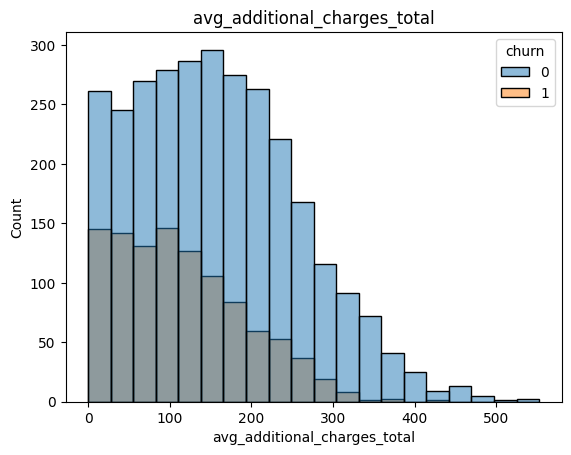

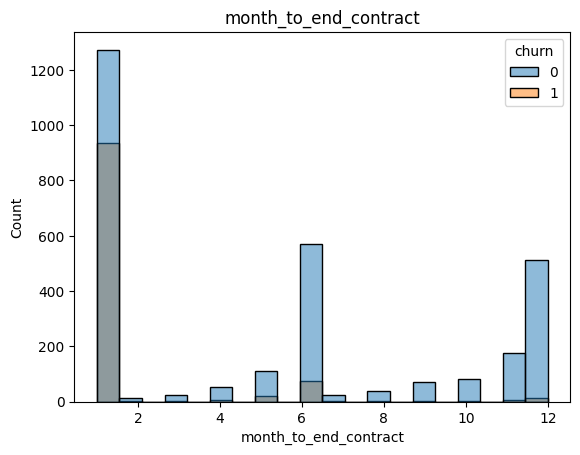

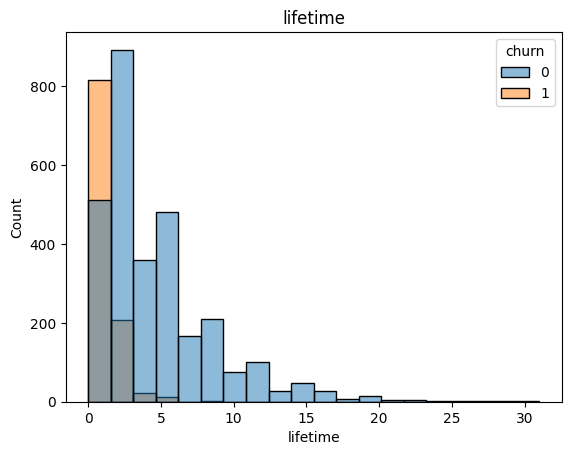

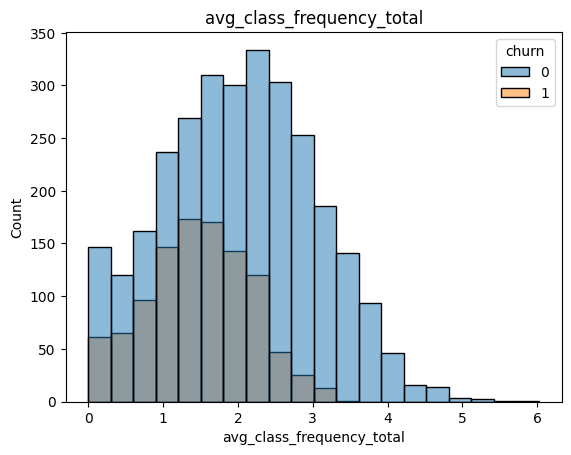

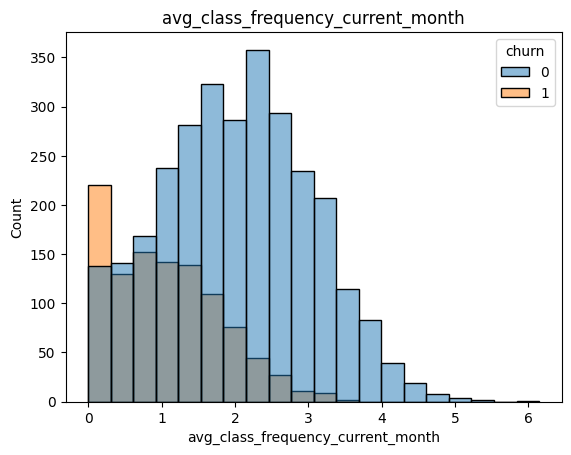

In [ ]:
# Crear histogramas de cada variable (excepto churn) comparando su distribución según churn
for col in df.columns:
    if col != 'churn':
        plt.figure()
        sns.histplot(data=df, x=col, hue='churn', bins=20)
        plt.title(col)
        plt.show()

### Análisis de churn: comparación de promedios y distribuciones

Se analizaron tanto los valores promedio (`groupby`) como las distribuciones de las variables para dos grupos:
- Clientes que **se quedaron (churn = 0)**
- Clientes que **cancelaron (churn = 1)**

---

### Principales diferencias observadas (promedios)

- **Frecuencia de visitas:**
  - Se quedaron: ~2.02 (total) y ~2.03 (mes actual)
  - Cancelaron: ~1.47 (total) y ~1.04 (mes actual)
  Los clientes que se van tienen menor actividad.

- **Duración del contrato:**
  - Se quedaron: ~5.77 meses
  - Cancelaron: ~1.73 meses
  Los contratos cortos están fuertemente asociados con churn.

- **Meses restantes de contrato:**
  - Se quedaron: ~5.28
  - Cancelaron: ~1.66
  Menor compromiso futuro = mayor riesgo de cancelación.

- **Lifetime (antigüedad):**
  - Se quedaron: ~4.71 meses
  - Cancelaron: ~0.99 meses
  Los clientes nuevos son más propensos a abandonar.

- **Gasto adicional:**
  - Se quedaron: ~158.45
  - Cancelaron: ~115.08
  Mayor inversión implica mayor compromiso.

- **Clases grupales:**
  - Mayor participación en clientes que se quedan (~0.46 vs ~0.27)
  La interacción social mejora la retención.

---

### Análisis de distribuciones

**Variables categóricas:**

- **gender:**  
  No muestra diferencias relevantes → no es un factor determinante.

- **near_location:**  
  Vivir o trabajar cerca reduce el churn → factor importante.

- **partner:**  
  Clientes con convenios empresariales presentan mayor retención.

- **promo_friends:**  
  Los clientes referidos tienden a quedarse más.

- **phone:**  
  No muestra impacto significativo.

- **group_visits:**  
  Participar en clases grupales reduce la probabilidad de cancelación.

---

**Variables numéricas:**

- **age:**  
  Clientes que cancelan son ligeramente más jóvenes (impacto leve).

- **contract_period:**  
  Contratos cortos → mayor churn.

- **month_to_end_contract:**  
  Menos meses restantes → mayor probabilidad de cancelación.

- **lifetime:**  
  Clientes recientes tienen mayor riesgo.

- **avg_additional_charges_total:**  
  Menor gasto → mayor churn.

- **avg_class_frequency_total & current_month:**  
  Menor frecuencia → mayor abandono  
   *Este es el indicador más fuerte.*

---

### Conclusión general

Los clientes que abandonan el gimnasio presentan un patrón claro:
- Baja frecuencia de visitas
- Bajo gasto adicional
- Contratos cortos
- Baja antigüedad
- Menor interacción (clases grupales)

---

### Insight clave

La **frecuencia de uso reciente**, junto con el **nivel de compromiso (contrato y gasto)**, son los factores más determinantes para predecir y prevenir la cancelación de clientes.

## Matriz de correlación

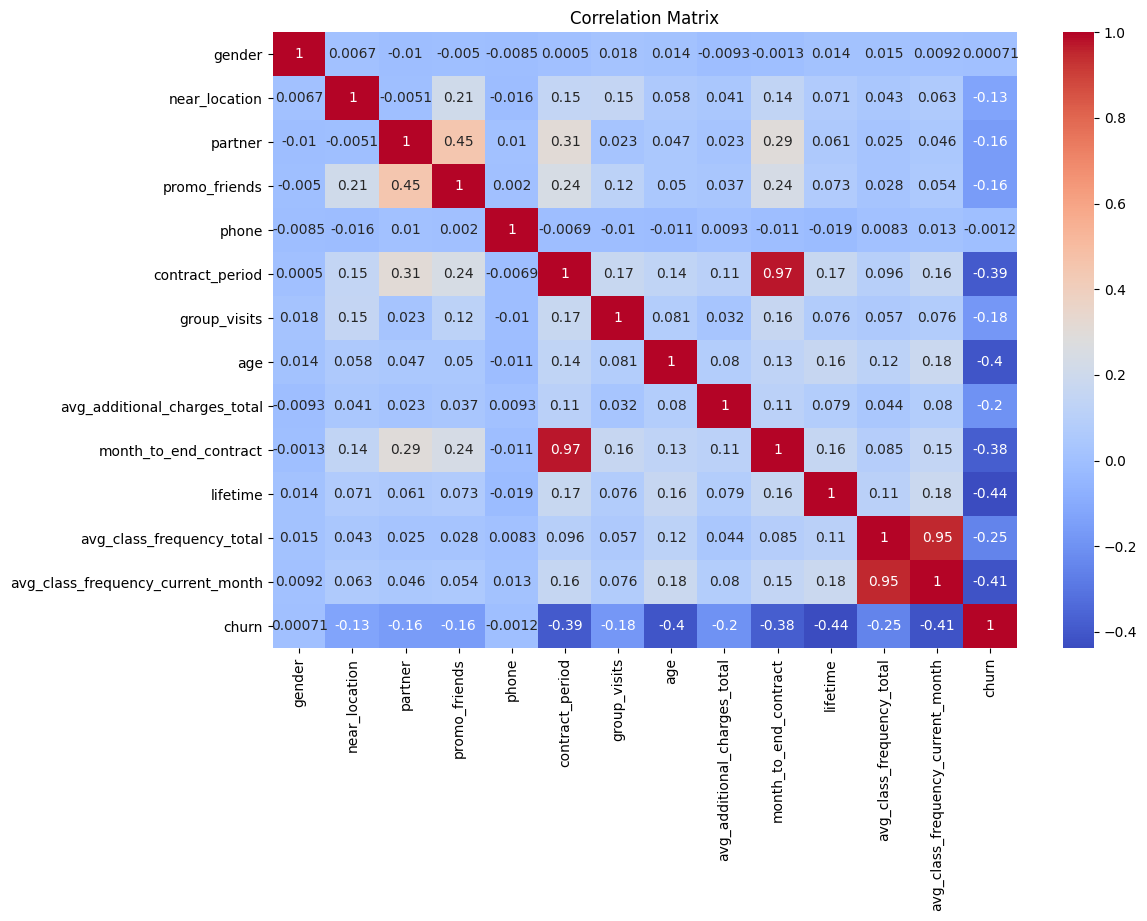

In [ ]:
# Calcular la matriz de correlación y visualizarla con un mapa de calor
corr = df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

### Análisis de matriz de correlación

Se analizó la correlación entre las variables del dataset para identificar relaciones relevantes y posibles factores asociados al churn.

---

### Correlaciones más destacadas

- **contract_period ↔ month_to_end_contract (~0.97):**
  - Correlación muy alta.
  Es lógico, ya que ambas variables representan la duración del contrato.

- **avg_class_frequency_total ↔ avg_class_frequency_current_month (~0.95):**
  - Correlación muy fuerte.
  Los hábitos recientes reflejan el comportamiento histórico del cliente.

---

### Variables más relacionadas con churn

Las correlaciones con la variable objetivo (`churn`) son principalmente negativas:

- **avg_class_frequency_current_month (~ -0.41)**
- **lifetime (~ -0.44)**
- **contract_period (~ -0.39)**
- **month_to_end_contract (~ -0.38)**
- **age (~ -0.40)**

Esto indica que:
- A mayor frecuencia de visitas → menor probabilidad de cancelación.
- A mayor antigüedad → mayor retención.
- Contratos más largos → menor churn.

---

### Otras observaciones

- Variables como **gender** y **phone** muestran correlaciones cercanas a 0 con churn.
  No son factores relevantes para predecir cancelación.

- **partner** y **promo_friends** tienen correlaciones leves negativas.
  Pueden influir, pero no son determinantes.

---

### Conclusión general

Las variables más importantes para entender y predecir el churn están relacionadas con:

- Nivel de actividad (frecuencia de visitas)
- Compromiso (duración del contrato)
- Antigüedad del cliente (lifetime)

---

### Insight clave

La **frecuencia de uso reciente**, junto con la **duración del contrato** y el **tiempo como cliente**, son los indicadores más fuertes para identificar clientes en riesgo de cancelación.

Además, existen variables altamente correlacionadas entre sí, lo que sugiere posible redundancia que debe considerarse al momento de construir modelos predictivos.

## Predecir la cancelación de usuarios

### Modelo de clasificación binario para clientes donde la característica objetivo es la marcha del usuario o usuaria el mes siguiente 

In [ ]:
# Separar variables (X, y) y dividir los datos en entrenamiento y validación
X = df.drop('churn', axis=1)
y = df['churn']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# Entrenar modelo de regresión logística y evaluar su desempeño en el conjunto de validación
model_lr = LogisticRegression(max_iter=1000, random_state=42)
model_lr.fit(X_train, y_train)

y_pred_lr = model_lr.predict(X_val)

print('Logistic Regression:')
print('Accuracy:', accuracy_score(y_val, y_pred_lr))
print('Precision:', precision_score(y_val, y_pred_lr))
print('Recall:', recall_score(y_val, y_pred_lr))

Logistic Regression:
Accuracy: 0.91625
Precision: 0.8729281767955801
Recall: 0.7821782178217822


### Evaluación del modelo: Regresión Logística

El modelo de regresión logística fue entrenado para predecir la cancelación de clientes en el siguiente mes.

**Resultados obtenidos:**
- Accuracy: 0.915
- Precision: 0.868
- Recall: 0.782

---

### Interpretación de métricas

- **Accuracy (91.5%)**
  - El modelo clasifica correctamente la gran mayoría de los casos.
  Buen desempeño general.

- **Precision (86.8%)**
  - Cuando el modelo predice que un cliente se va, acierta en la mayoría de los casos.
  Bajo nivel de falsos positivos.

- **Recall (78.2%)**
  - El modelo detecta aproximadamente el 78% de los clientes que realmente cancelan.
  Aún hay margen de mejora para identificar todos los casos de churn.
---

### Insight clave

El modelo es útil para identificar clientes con alta probabilidad de cancelar, pero se podría optimizar para mejorar la detección de todos los casos de churn, especialmente si el objetivo del negocio es prevenir la mayor cantidad posible de cancelaciones.

### Modelo Random Forest para predecir la cancelación de usuarios

In [ ]:
# Entrenar modelo Random Forest y evaluar su desempeño en el conjunto de validación
model_rf = RandomForestClassifier(random_state=42)
model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_val)

print('Random Forest:')
print('Accuracy:', accuracy_score(y_val, y_pred_rf))
print('Precision:', precision_score(y_val, y_pred_rf))
print('Recall:', recall_score(y_val, y_pred_rf))

Random Forest:
Accuracy: 0.91
Precision: 0.8494623655913979
Recall: 0.7821782178217822


### Evaluación y comparación de modelos

Se evaluaron dos modelos de clasificación utilizando los datos de validación: **Regresión Logística** y **Random Forest**.

---

### Resultados

**Regresión Logística:**
- Accuracy: 0.915
- Precision: 0.868
- Recall: 0.782

**Random Forest:**
- Accuracy: 0.907
- Precision: 0.847
- Recall: 0.772

---

### Comparación

- La **Regresión Logística** presenta mejores resultados en las tres métricas:
  - Mayor exactitud (accuracy)
  - Mayor precisión (precision)
  - Mayor capacidad de detectar casos reales de cancelación (recall)

- El modelo **Random Forest**, aunque es más complejo, no supera el desempeño del modelo lineal en este caso.

---

### Conclusión

El modelo que dio mejores resultados fue la **Regresión Logística**, ya que obtuvo valores superiores en todas las métricas evaluadas.

---

### Interpretación

Esto sugiere que la relación entre las variables y la cancelación de clientes es relativamente simple y puede ser capturada eficazmente por un modelo lineal, sin necesidad de utilizar modelos más complejos.

# Clústeres

### Pasaremos a estandarizar los datos

In [ ]:
# Escalar las variables para normalizar los datos antes de aplicar modelos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Matriz de distancias

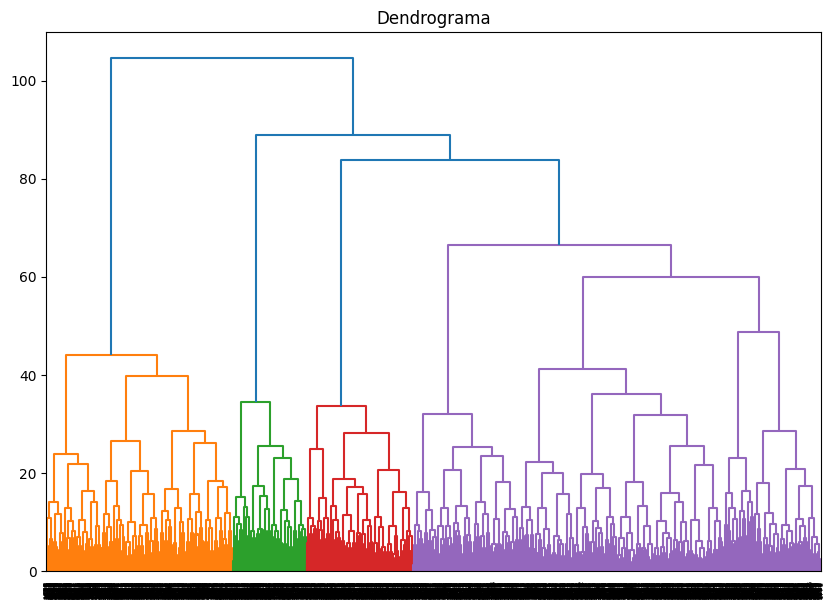

In [ ]:
# Aplicar clustering jerárquico y visualizar la estructura con un dendrograma
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(10, 7))
dendrogram(linked)
plt.title('Dendrograma')
plt.show()

In [ ]:
# Aplicar K-Means para agrupar los datos y asignar etiquetas de cluster al DataFrame
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df['cluster'] = clusters

In [ ]:
# Analizar los clusters calculando el promedio de cada variable por grupo
df.groupby('cluster').mean()

,gender,near_location,partner,promo_friends,phone,contract_period,group_visits,age,avg_additional_charges_total,month_to_end_contract,lifetime,avg_class_frequency_total,avg_class_frequency_current_month,churn
cluster,,,,,,,,,,,,,,
0,0.502370,0.949447,0.829384,0.998420,1.0,3.097946,0.448657,29.104265,141.774331,2.887836,3.772512,1.770536,1.669581,0.246445
1,0.554556,0.849269,0.263217,0.052868,1.0,2.606299,0.436445,30.008999,159.774265,2.419573,4.780652,2.745505,2.733173,0.089989
2,0.499422,0.937572,0.737572,0.478613,1.0,11.854335,0.546821,29.905202,163.509804,10.812717,4.677457,2.006405,1.998179,0.021965
3,0.485738,0.718011,0.299919,0.018745,1.0,1.914425,0.276284,28.083945,129.496414,1.821516,2.195599,1.225192,0.967967,0.572942
4,0.523316,0.862694,0.471503,0.305699,0.0,4.777202,0.427461,29.297927,144.208179,4.466321,3.940415,1.854211,1.723967,0.266839


### Segmentación de clientes con K-means (n = 5)

Se aplicó el algoritmo **K-means** para segmentar a los clientes en 5 clústeres, basándonos en el análisis previo del dendrograma.

---

### Características de los clústeres

**Cluster 0:**
- Alta proporción de clientes con partner y promo_friends
- Frecuencia media de visitas (~1.7)
- Churn moderado (~24%)
Clientes relativamente comprometidos, pero con margen de mejora.

---

**Cluster 1:**
- Alta frecuencia de visitas (~2.7)
- Mayor gasto adicional (~159)
- Alta antigüedad (~4.78 meses)
- Churn muy bajo (~8%)
**Clientes más leales y activos**.

---

**Cluster 2:**
- Contratos más largos (~11.85 meses)
- Mayor gasto adicional (~163)
- Alta frecuencia (~2.0)
- Churn muy bajo (~2%)
**Clientes premium y altamente comprometidos**.

---

**Cluster 3:**
- Baja frecuencia (~1.22 total, ~0.96 actual)
- Baja antigüedad (~2.19 meses)
- Bajo gasto (~129)
- Churn muy alto (~57%)
**Clientes en alto riesgo de cancelación**.

---

**Cluster 4:**
- Frecuencia media (~1.85)
- Contratos relativamente largos (~4.77)
- Churn moderado (~26%)
Clientes estables pero no completamente fidelizados.

---

### Análisis general

- Existen diferencias claras entre los grupos en términos de:
  - Frecuencia de visitas
  - Duración del contrato
  - Gasto adicional
  - Antigüedad

- El churn varía significativamente entre clústeres:
  - Más alto en el **cluster 3**
  - Más bajo en los **clusters 1 y 2**

---

### Conclusión

El modelo K-means permitió identificar segmentos de clientes con comportamientos distintos.

- **Clusters 1 y 2:** clientes leales → deben mantenerse satisfechos.
- **Cluster 3:** clientes en riesgo → prioridad para estrategias de retención.
- **Clusters 0 y 4:** grupo intermedio → potencial de fidelización.

---

### Insight clave

La combinación de **baja frecuencia, baja antigüedad y bajo gasto** define al grupo con mayor riesgo de cancelación, mientras que **alta actividad y contratos largos** caracterizan a los clientes más valiosos.

### Análisis de valores medios por clúster

Al observar los promedios de los clústeres, se identifican diferencias claras en el comportamiento de los clientes.

---

### Hallazgos clave

- **Clusters 1 y 2:**
  - Mayor frecuencia de visitas, mayor gasto y contratos más largos.
  - Muy bajo churn.
  Clientes más leales y comprometidos.

- **Cluster 3:**
  - Baja frecuencia, baja antigüedad y menor gasto.
  - **Mayor churn (~57%)**.
  Grupo con mayor riesgo de cancelación.

- **Clusters 0 y 4:**
  - Comportamiento intermedio.
  - Churn moderado.
  Clientes con potencial de fidelización.

---

### Conclusión

Sí, se observa un patrón claro:
A mayor actividad, compromiso y antigüedad, menor probabilidad de cancelación.

Los clientes nuevos y poco activos son los más propensos a abandonar.

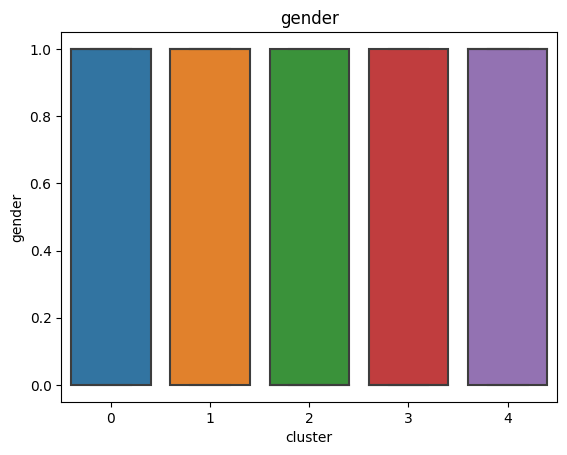

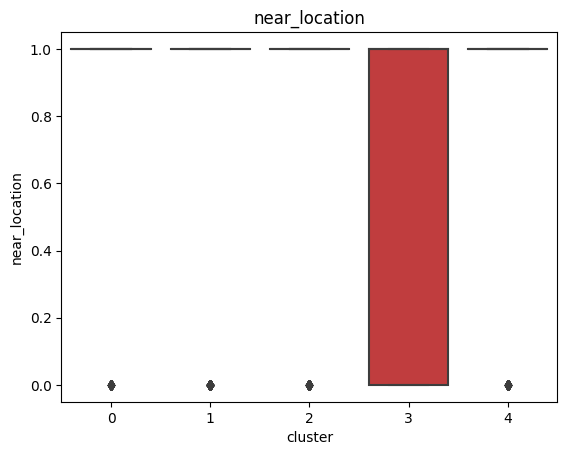

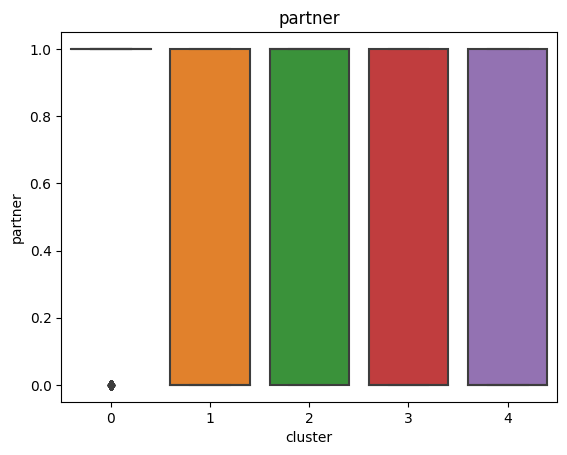

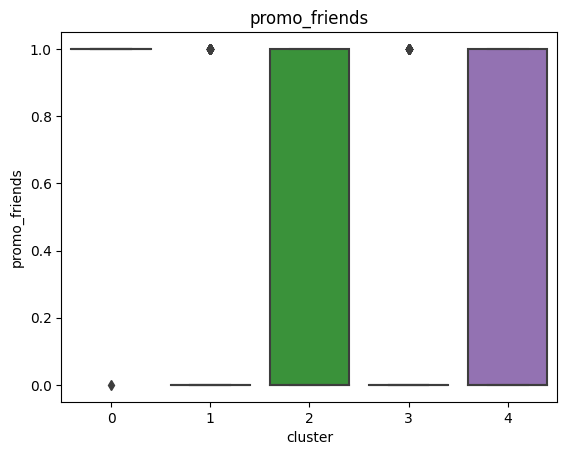

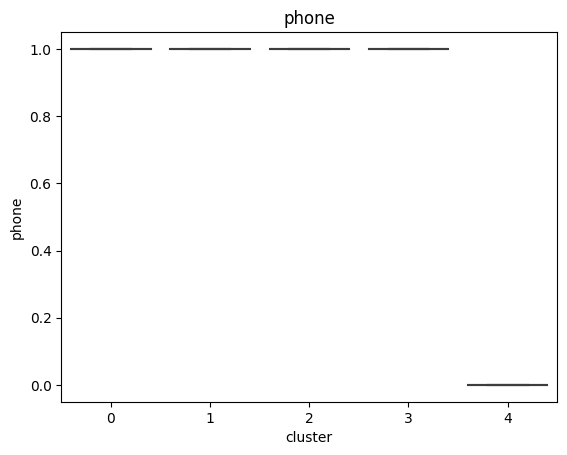

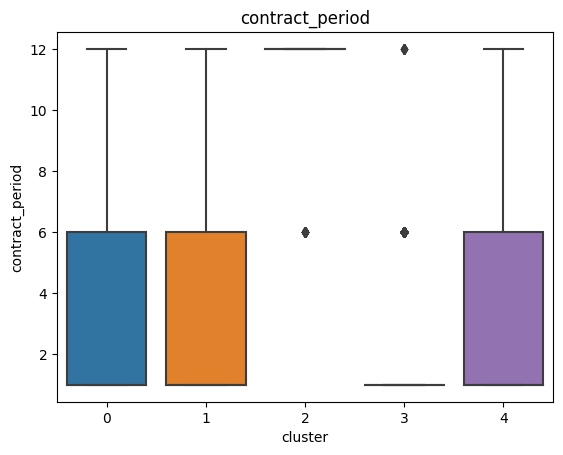

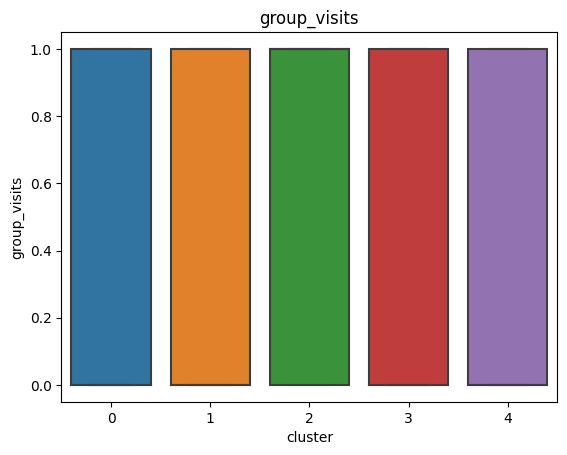

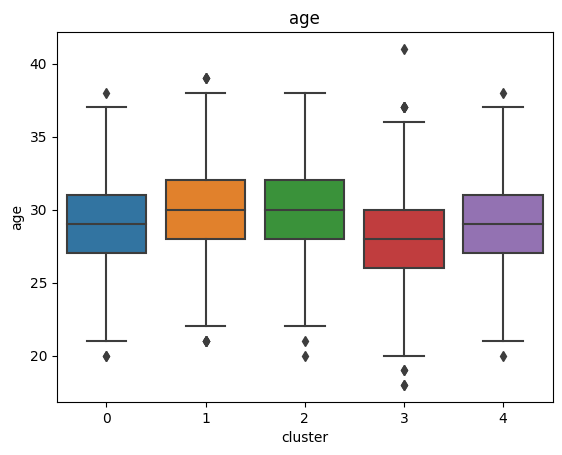

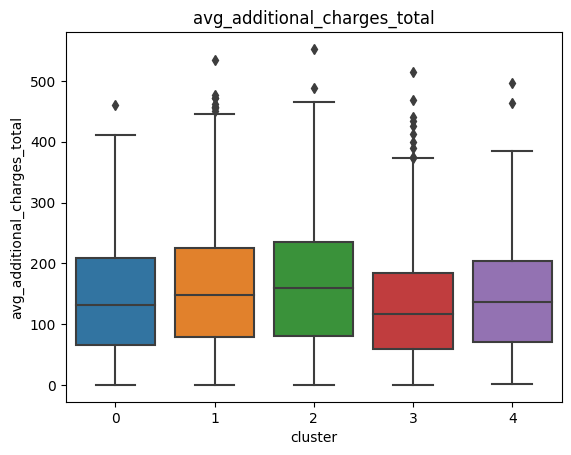

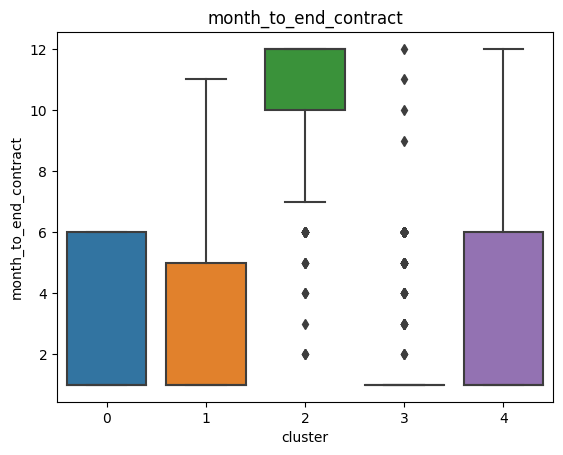

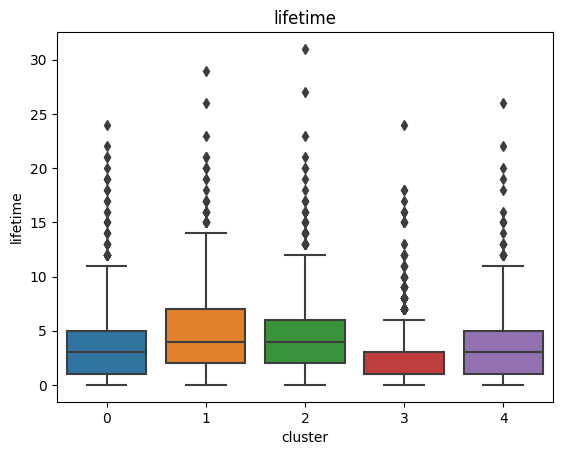

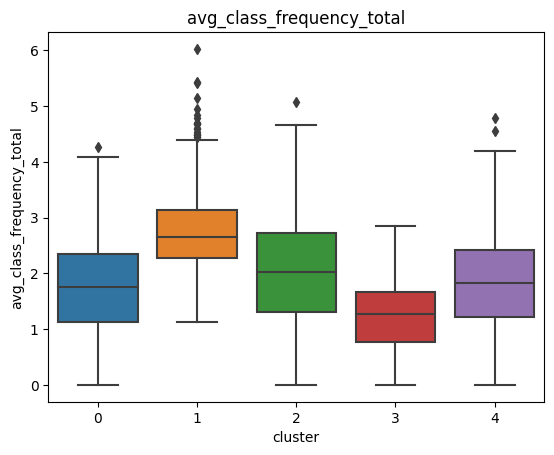

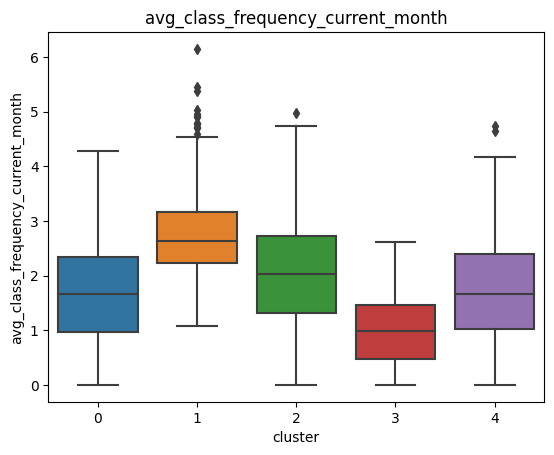

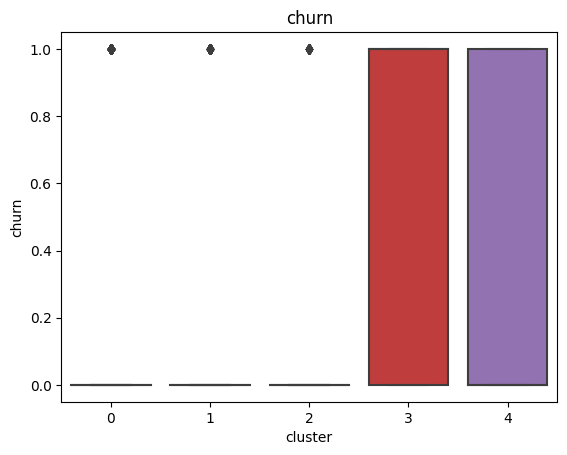

In [ ]:
# Visualizar la distribución de cada variable por cluster mediante boxplots
for col in df.columns:
    if col not in ['cluster', 'Churn']:
        plt.figure()
        sns.boxplot(x='cluster', y=col, data=df)
        plt.title(col)
        plt.show()

### Distribución de características por clúster

Al analizar las distribuciones de las variables por clúster, se observan diferencias claras entre los grupos.

---

### Hallazgos principales

- **Cluster 1:**
  - Mayor frecuencia de visitas (total y actual).
  Clientes más activos.

- **Cluster 2:**
  - Contratos más largos y más meses restantes.
  Clientes más comprometidos a largo plazo.

- **Cluster 3:**
  - Menor frecuencia de visitas.
  - Menor gasto adicional.
  - Menor antigüedad.
  Grupo claramente menos activo y más inestable.

- **Cluster 4:**
  - Valores intermedios en la mayoría de variables.
  Comportamiento moderado.

---

### Variable churn

- El **cluster 3** concentra la mayor cantidad de cancelaciones.
- Los **clusters 1 y 2** presentan muy bajo churn.

---

### Otras observaciones

- Variables como **gender, phone y group_visits** no muestran diferencias claras entre clústeres.
- Las diferencias más importantes se concentran en:
  - Frecuencia de visitas
  - Duración del contrato
  - Gasto adicional
  - Antigüedad (lifetime)

---

### Conclusión

Sí, las distribuciones muestran un patrón claro:

Los clientes más activos y comprometidos (clusters 1 y 2) tienen menor churn, mientras que los clientes menos activos (cluster 3) presentan el mayor riesgo de cancelación.

## Tasa de cancelación para cada clúster

In [ ]:
# Calcular la tasa de churn promedio en cada cluster
df.groupby('cluster')['churn'].mean()

cluster
0    0.246445
1    0.089989
2    0.021965
3    0.572942
4    0.266839
Name: churn, dtype: float64

### Tasa de cancelación por clúster

Se calculó la tasa promedio de cancelación (`churn`) para cada clúster:

- Cluster 0: 24.6%
- Cluster 1: 8.9%
- Cluster 2: 2.2%
- Cluster 3: 57.3%
- Cluster 4: 26.7%

---

### Análisis

Sí, las tasas de cancelación **difieren significativamente** entre los clústeres.

- **Cluster 3:**
  - Mayor tasa de churn (~57%)
  Grupo más propenso a cancelar.

- **Cluster 0 y 4:**
  - Tasa intermedia (~25–27%)
  Clientes con riesgo moderado.

- **Cluster 1:**
  - Baja tasa (~9%)
  Clientes bastante leales.

- **Cluster 2:**
  - Muy baja tasa (~2%)
  **Clientes más leales y estables**.

---

### Conclusión

- Los clientes más propensos a irse pertenecen al **cluster 3**.
- Los clientes más leales están en los **clusters 1 y 2**, especialmente el cluster 2.

---

### Insight clave

Existe una clara relación entre el nivel de actividad y compromiso del cliente y la tasa de cancelación:  
A mayor engagement, menor churn.

# Conclusiones y recomendaciones

### Conclusiones principales

1. La **frecuencia de visitas** es el factor más importante para la retención.
2. Los **contratos largos** y mayor tiempo como cliente reducen significativamente el churn.
3. Los clientes con **mayor gasto adicional** y participación en servicios (clases grupales) son más leales.
4. Existe un grupo claro de alto riesgo (cluster 3): clientes nuevos, poco activos y con bajo compromiso.

---

### Recomendaciones estratégicas

**1. Identificar y actuar sobre clientes en riesgo**
- Detectar usuarios con baja frecuencia de visitas y poca antigüedad.
- Implementar campañas de seguimiento (emails, llamadas, promociones personalizadas).

---

**2. Incentivar la actividad del cliente**
- Ofrecer descuentos o beneficios por asistir con mayor frecuencia.
- Promover clases grupales, retos fitness o programas de fidelización.

---

**3. Fomentar contratos a largo plazo**
- Ofrecer descuentos en membresías de 6 o 12 meses.
- Crear planes atractivos que aumenten el compromiso del cliente.

---

**4. Aumentar la interacción y el engagement**
- Promocionar servicios adicionales (cafetería, productos, entrenamientos personalizados).
- Implementar programas de referidos (trae a un amigo).

---

### Conclusión general

El análisis permite identificar patrones claros de comportamiento que predicen la cancelación.  
Aplicando estrategias enfocadas en **aumentar la actividad, el compromiso y la experiencia del cliente**, es posible reducir significativamente la tasa de churn.